In [ ]:
# ===== DATA LOADING AND PROCESSING =====
import json
import pandas as pd

# ===== CONFIGURATION =====
FEAR_ZONE_MIN = 0.5    # Fear zone starts at this value
FEAR_ZONE_MAX = 1.0    # Fear zone ends at this value
MARGIN = 0.5  # Margin in seconds on each side of the region

# FILENAME = 'fear_results/Calibration_log_001_results.json'
FILENAME_CALIBRATION = 'fear_results/Calibration_log_11251606_001_results.json'
# FILENAME_STANDARD = 'fear_results/Pupil_log_Standard_11251608_001_results.json'
FILENAME_AI = 'fear_results/Pupil_log_AI_11251615_001_results.json'
# =========================

def load_file(filename):
    # Load the results
    with open(filename, 'r') as f:
        results = json.load(f)

    # Convert to DataFrame
    df = pd.DataFrame(results['timeline'])

    # Ensure numeric types for all columns
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col], errors='ignore')
        except:
            pass

    # Create time index starting from 0
    df['time'] = [i * 0.5 for i in range(len(df))]  # 0.5 seconds per sample

    # Find local maxima and minima for fear level
    df['is_peak'] = (df['fear_level'] > df['fear_level'].shift(1)) & (df['fear_level'] > df['fear_level'].shift(-1))
    df['is_valley'] = (df['fear_level'] < df['fear_level'].shift(1)) & (df['fear_level'] < df['fear_level'].shift(-1))
    df.loc[0, 'is_peak'] = df.loc[0, 'is_valley'] = False
    df.loc[df.index[-1], 'is_peak'] = df.loc[df.index[-1], 'is_valley'] = False

    # Normalize pupil_size to 0-1 range
    pupil_min = df['pupil_size'].min()
    pupil_max = df['pupil_size'].max()
    df['pupil_normalized'] = (df['pupil_size'] - pupil_min) / (pupil_max - pupil_min)

    # Print data statistics
    print("\nData statistics:")
    for col in ['fear_level', 'luminance', 'pupil_size']:
        if col in df.columns:
            print(f"{col} - Min: {df[col].min():.4f}, Max: {df[col].max():.4f}")

    # Show first few rows
    print("\nFirst few rows of data:")
    print(df[['time', 'fear_level', 'luminance', 'pupil_size', 'pupil_normalized']].head())

    return df

calibration_df = load_file(FILENAME_CALIBRATION)
ai_df = load_file(FILENAME_AI)


Data statistics:
fear_level - Min: 0.2570, Max: 0.9580
luminance - Min: 0.0000, Max: 1.0000
pupil_size - Min: 2.9512, Max: 5.4857

First few rows of data:
   time  fear_level  luminance  pupil_size  pupil_normalized
0   0.0    0.795518   0.000000    5.424894          0.975995
1   0.5    0.740036   0.062682    5.282172          0.919684
2   1.0    0.850352   0.125364    5.485734          1.000000
3   1.5    0.673967   0.187804    5.095177          0.845904
4   2.0    0.539600   0.250728    4.812626          0.734422

Data statistics:
fear_level - Min: 0.2726, Max: 0.9667
luminance - Min: 0.0521, Max: 0.6590
pupil_size - Min: 3.9455, Max: 6.4068

First few rows of data:
   time  fear_level  luminance  pupil_size  pupil_normalized
0   0.0    0.841136   0.418181    5.815851          0.759905
1   0.5    0.394048   0.408575    5.362346          0.575649
2   1.0    0.856889   0.394186    4.529728          0.237361
3   1.5    0.785045   0.396573    4.608668          0.269434
4   2.0    0.3681

C:\Users\Michael\AppData\Local\Temp\ipykernel_21208\2297510734.py:27: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
C:\Users\Michael\AppData\Local\Temp\ipykernel_21208\2297510734.py:27: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


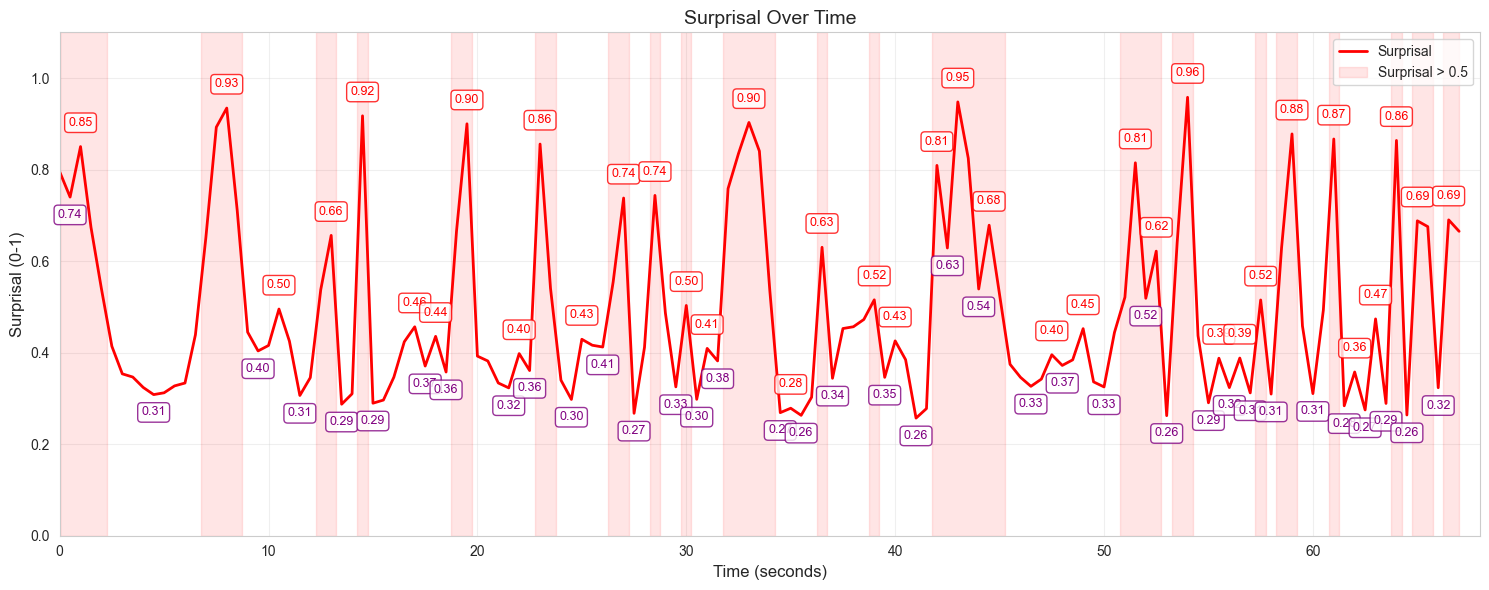

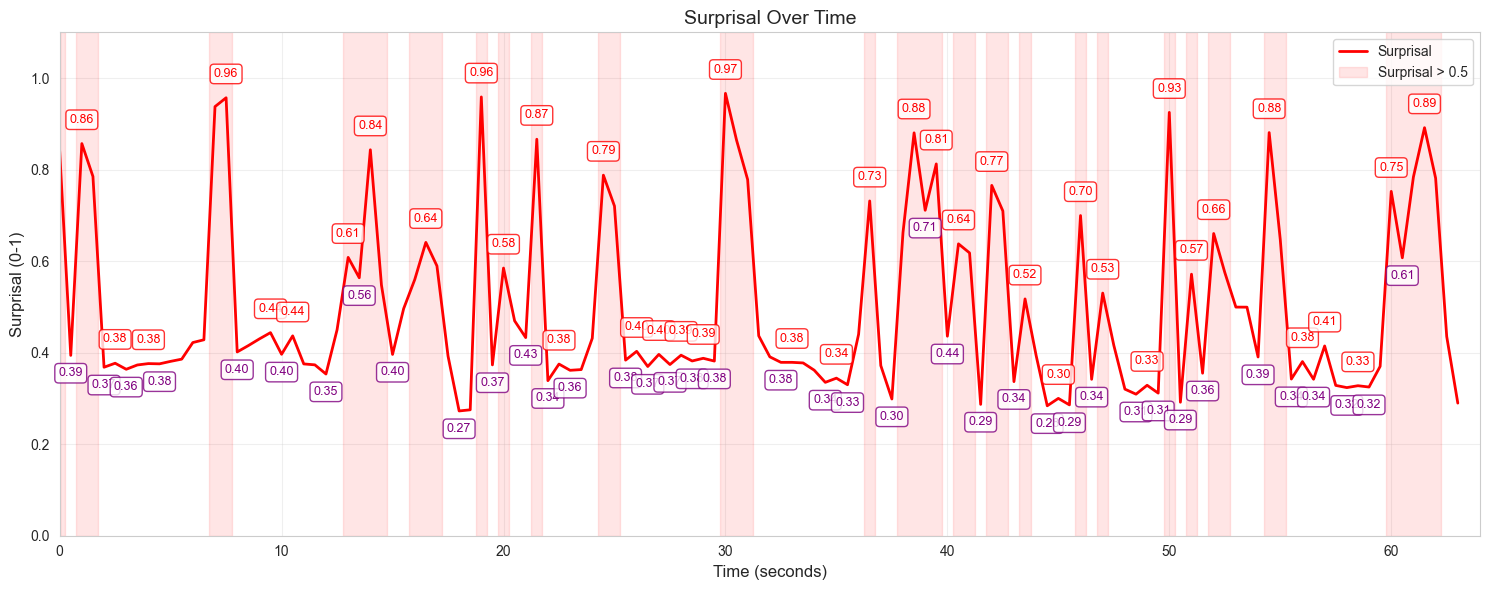

In [126]:
def visualization_oneline(df: pd.DataFrame):
    # ===== VISUALIZATION =====
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Set up the plot with an explicit axis
    fig, ax = plt.subplots(figsize=(15, 6))
    sns.set_style("whitegrid")

    # Plot fear level
    ax.plot(df['time'], df['fear_level'], 
            label='Surprisal', 
            color='red', 
            linewidth=2)

    # Find regions where fear_level is above FEAR_ZONE_MIN
    above_threshold = df['fear_level'] >= FEAR_ZONE_MIN
    regions = []
    current_region = None

    # Identify all regions above threshold
    for i, (time, is_above) in enumerate(zip(df['time'], above_threshold)):
        if is_above:
            if current_region is None:
                current_region = [time, time]
            else:
                current_region[1] = time
        elif current_region is not None:
            regions.append((current_region[0], current_region[1]))
            current_region = None

    # Add the last region if it exists
    if current_region is not None:
        regions.append((current_region[0], current_region[1]))

    # Create bands for each region with margins
    for start, end in regions:
        time_diff = df['time'].diff().mean()
        margin = min(MARGIN, time_diff / 2)
        start_with_margin = max(0, start - margin)
        end_with_margin = min(df['time'].max(), end + margin)
        ax.axvspan(start_with_margin, end_with_margin, 
                alpha=0.1, color='red', label='_nolegend_')

    # Add annotations using the same axis object
    for _, point in df[df['is_peak'] | df['is_valley']].iterrows():
        y_offset = 15 if point['is_peak'] else -15
        color = 'red' if point['is_peak'] else 'purple'
        ax.annotate(f"{point['fear_level']:.2f}", 
                (point['time'], point['fear_level']),
                xytext=(0, y_offset),
                textcoords='offset points',
                ha='center',
                color=color,
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', 
                            fc='white', 
                            alpha=0.8, 
                            edgecolor=color))

    # Add a single legend entry for all fear zones
    ax.axvspan(0, 0, alpha=0.1, color='red', 
            label=f'Surprisal > {FEAR_ZONE_MIN}')

    # Formatting
    ax.set_title('Surprisal Over Time', fontsize=14)
    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_ylabel('Surprisal (0-1)', fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_xlim(0, df['time'].max() + 1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

visualization_oneline(calibration_df)
visualization_oneline(ai_df)

Plot saved to: c:\Users\Michael\Desktop\AcroGen\Backend\Scripts\visualizations\Pupil_log_AI_11251615_001_results.png


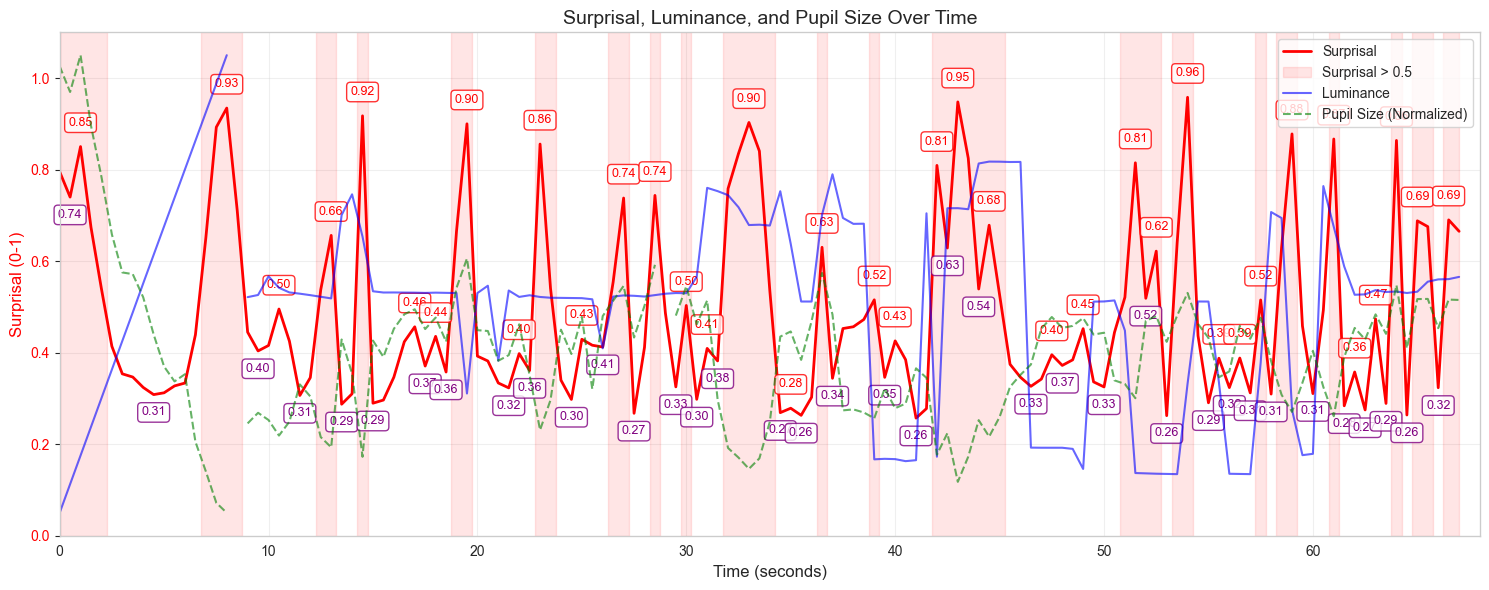

Plot saved to: c:\Users\Michael\Desktop\AcroGen\Backend\Scripts\visualizations\Pupil_log_AI_11251615_001_results.png


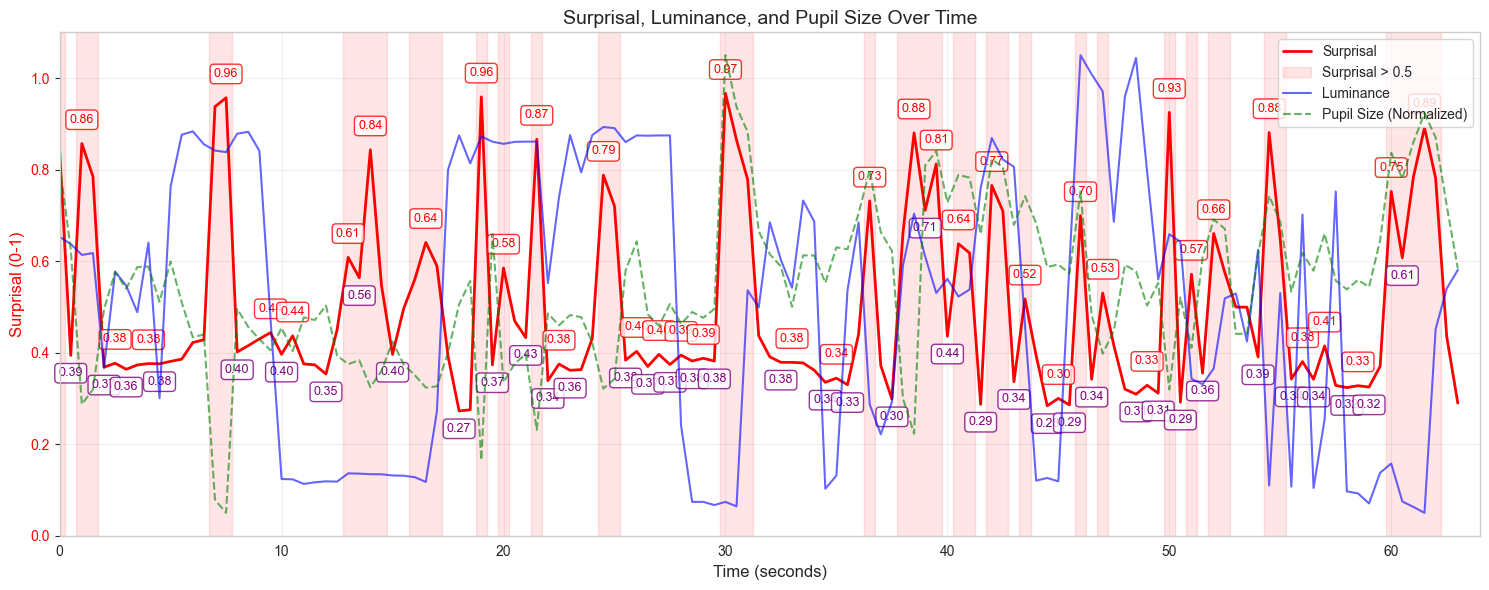

In [127]:
def visualization_threelines(df: pd.DataFrame):
    # ===== VISUALIZATION =====
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    from pathlib import Path

    # Set up the figure and primary axis
    fig, ax1 = plt.subplots(figsize=(15, 6))
    sns.set_style("whitegrid")

    # Plot fear level on primary y-axis
    ax1.set_xlabel('Time (seconds)', fontsize=12)
    ax1.set_ylabel('Surprisal (0-1)', color='red', fontsize=12)
    fear_line = ax1.plot(df['time'], df['fear_level'], 
                        color='red', 
                        linewidth=2,
                        label='Surprisal')
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.set_ylim(0, 1.1)
    ax1.set_xlim(0, df['time'].max() + 1)

    # Find regions where fear_level is above FEAR_ZONE_MIN
    above_threshold = df['fear_level'] >= FEAR_ZONE_MIN
    regions = []
    current_region = None

    # Identify all regions above threshold
    for i, (time, is_above) in enumerate(zip(df['time'], above_threshold)):
        if is_above:
            if current_region is None:
                current_region = [time, time]
            else:
                current_region[1] = time
        elif current_region is not None:
            regions.append((current_region[0], current_region[1]))
            current_region = None

    # Add the last region if it exists
    if current_region is not None:
        regions.append((current_region[0], current_region[1]))

    # Create bands for each region with margins
    for start, end in regions:
        # Calculate time difference between points to determine margin
        time_diff = df['time'].diff().mean()
        margin = min(MARGIN, time_diff / 2)  # Don't exceed half the time difference
        
        # Apply margins
        start_with_margin = max(0, start - margin)
        end_with_margin = min(df['time'].max(), end + margin)
        
        # Create the band
        ax1.axvspan(start_with_margin, 
                    end_with_margin, 
                    alpha=0.1, 
                    color='red',
                    label='_nolegend_')

    # Create second y-axis for luminance
    ax2 = ax1.twinx()
    luminance_line = ax2.plot(df['time'], df['luminance'],
                            color='blue', 
                            alpha=0.6,
                            linewidth=1.5,
                            label='Luminance')
    ax2.set_yticklabels([])
    ax2.set_yticks([])
    ax2.set_ylabel('')

    # Create third y-axis for pupil size
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 0))
    pupil_line = ax3.plot(df['time'], df['pupil_normalized'],
                        color='green',
                        alpha=0.6,
                        linewidth=1.5,
                        linestyle='--',
                        label='Pupil Size (Normalized)')
    ax3.set_yticklabels([])
    ax3.set_yticks([])
    ax3.set_ylabel('')

    # Add value annotations for all peaks and valleys
    for _, point in df[df['is_peak'] | df['is_valley']].iterrows():
        color = 'red' if point['is_peak'] else 'purple'
        y_offset = 15 if point['is_peak'] else -15
        ax1.annotate(f"{point['fear_level']:.2f}", 
                    (point['time'], point['fear_level']),
                    xytext=(0, y_offset), 
                    textcoords='offset points',
                    ha='center',
                    color=color,
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, edgecolor=color))

    # Add a single legend entry for all fear zones
    ax1.axvspan(0, 0, alpha=0.1, color='red', 
            label=f'Surprisal > {FEAR_ZONE_MIN}')

    # Formatting
    ax1.set_title('Surprisal, Luminance, and Pupil Size Over Time', fontsize=14)
    ax1.set_xlabel('Time (seconds)', fontsize=12)
    ax1.set_ylabel('Surprisal (0-1)', fontsize=12)
    ax1.set_ylim(0, 1.1)
    ax1.set_xlim(0, df['time'].max() + 1)
    ax1.grid(True, alpha=0.3)

    # Combine legends from all axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, 
            labels1 + labels2 + labels3, 
            loc='upper right')

    plt.tight_layout()

    # Save the figure using the original filename (without extension)
    output_dir = 'visualizations'
    os.makedirs(output_dir, exist_ok=True)
    input_filename = Path(FILENAME).stem
    output_path = os.path.join(output_dir, f'{input_filename}.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {os.path.abspath(output_path)}")

    plt.show()

visualization_threelines(calibration_df)
visualization_threelines(ai_df)

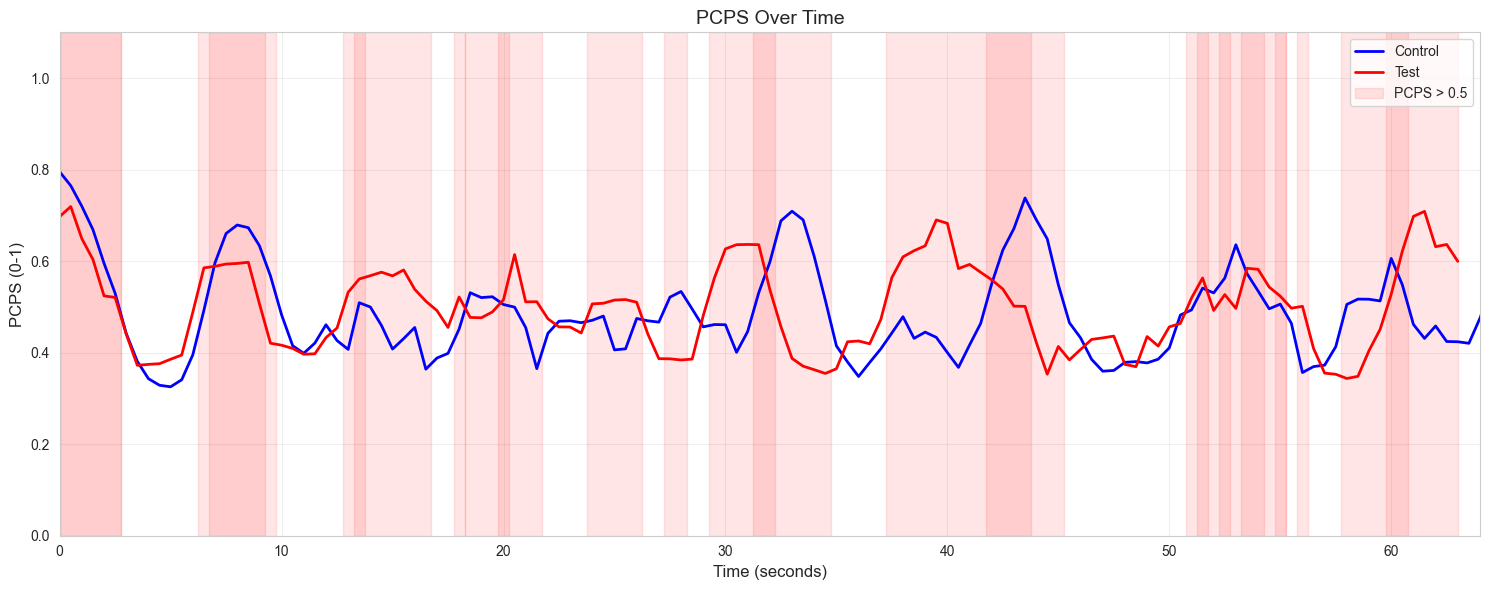

In [138]:
def visualization_moving_average(dfs: list[pd.DataFrame], names: list[str], colors: list[str]):
    # ===== VISUALIZATION =====
    import matplotlib.pyplot as plt
    import seaborn as sns

    WINDOW_SIZE = 6

    # Set up the plot with an explicit axis
    fig, ax = plt.subplots(figsize=(15, 6))
    sns.set_style("whitegrid")

    for df, name, color in zip(dfs, names, colors):

        # Calculate moving average (window size = 5, adjust as needed)
        df['fear_level_smoothed'] = df['fear_level'].rolling(window=WINDOW_SIZE, 
                                                        min_periods=1, 
                                                        center=True).mean()

        # Plot original and smoothed fear level
        # original_line = ax.plot(df['time'], df['fear_level'], 
        #                        label='Surprisal (Original)', 
        #                        color='red', 
        #                        alpha=0.3,
        #                        linewidth=1)

        smoothed_line = ax.plot(df['time'], df['fear_level_smoothed'], 
                            label=name, 
                            color=color, 
                            linewidth=2)

        # Find regions where smoothed fear_level is above FEAR_ZONE_MIN
        above_threshold = df['fear_level_smoothed'] >= FEAR_ZONE_MIN
        regions = []
        current_region = None

        # Identify all regions above threshold
        for i, (time, is_above) in enumerate(zip(df['time'], above_threshold)):
            if is_above:
                if current_region is None:
                    current_region = [time, time]
                else:
                    current_region[1] = time
            elif current_region is not None:
                regions.append((current_region[0], current_region[1]))
                current_region = None

        # Add the last region if it exists
        if current_region is not None:
            regions.append((current_region[0], current_region[1]))

        # Create bands for each region with margins
        for start, end in regions:
            time_diff = df['time'].diff().mean()
            margin = min(MARGIN, time_diff / 2)
            start_with_margin = max(0, start - margin)
            end_with_margin = min(df['time'].max(), end + margin)
            ax.axvspan(start_with_margin, end_with_margin, 
                    alpha=0.1, color='red', label='_nolegend_')

        # Add annotations using the smoothed data
        # peaks_valleys = df[df['is_peak'] | df['is_valley']].copy()
        # for _, point in peaks_valleys.iterrows():
        #     y_offset = 15 if point['is_peak'] else -15
        #     color = 'red' if point['is_peak'] else 'purple'
        #     ax.annotate(f"{point['fear_level_smoothed']:.2f}", 
        #                (point['time'], point['fear_level_smoothed']),
        #                xytext=(0, y_offset),
        #                textcoords='offset points',
        #                ha='center',
        #                color=color,
        #                fontsize=9,
        #                bbox=dict(boxstyle='round,pad=0.3', 
        #                         fc='white', 
        #                         alpha=0.8, 
        #                         edgecolor=color))

    # Add a single legend entry for all fear zones
    ax.axvspan(0, 0, alpha=0.1, color='red', 
            label=f'PCPS > {FEAR_ZONE_MIN}')

    # Formatting
    ax.set_title('PCPS Over Time', fontsize=14)
    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_ylabel('PCPS (0-1)', fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_xlim(0, df['time'].max() + 1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

visualization_moving_average([calibration_df, ai_df], ['Control', 'Test'], ['blue', 'red'])